# Etap 6. projektu – Interpretacja wyników

Projekt: **Automatyczne wykrywanie liczby klastrów w danych**

W etapie 5 porównano modele klasteryzacji (K-Means, Agglomerative Clustering oraz DBSCAN). Celem obecnego etapu jest interpretacja działania najlepszego modelu oraz identyfikacja cech mających największy wpływ na przypisanie klientów do poszczególnych klastrów.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay

import shap

pd.set_option("display.max_columns", 100)
sns.set_theme()


c:\Users\PC COMPUTER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Wczytanie danych

Zakładamy, że najlepszym modelem wybranym w etapie 5 był K-Means. W celu interpretacji tworzymy model zastępczy (surrogate model), który przewiduje przypisanie do klastra.


In [2]:
data = pd.read_parquet('../data/processed/stage3_eda_ready.parquet')

exclude_columns = [
    'ID',
    'default.payment.next.month'
]

features = [c for c in data.columns if c not in exclude_columns]

X = data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

print('Liczba klastrów:', len(np.unique(cluster_labels)))


Liczba klastrów: 4


# Model interpretacyjny

Ponieważ K-Means nie udostępnia bezpośrednio mechanizmu feature importance, budujemy model Random Forest przewidujący etykietę klastra.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    cluster_labels,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print('Dokładność surrogate model:', rf.score(X_test, y_test))


Dokładność surrogate model: 0.9843333333333333


# 1. Feature Importance

In [5]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(15)


,Feature,Importance
9,EDUCATION_3,0.300053
2,AVG_LIMIT_UTILIZATION,0.182829
0,LIMIT_BAL,0.127491
3,PAY_MEAN,0.121879
6,PAY_TO_BILL_RATIO,0.072866
8,EDUCATION_2,0.053553
4,PAY_MAX,0.052495
10,EDUCATION_4,0.038331
1,AGE,0.028339
5,PAY_TREND,0.009216


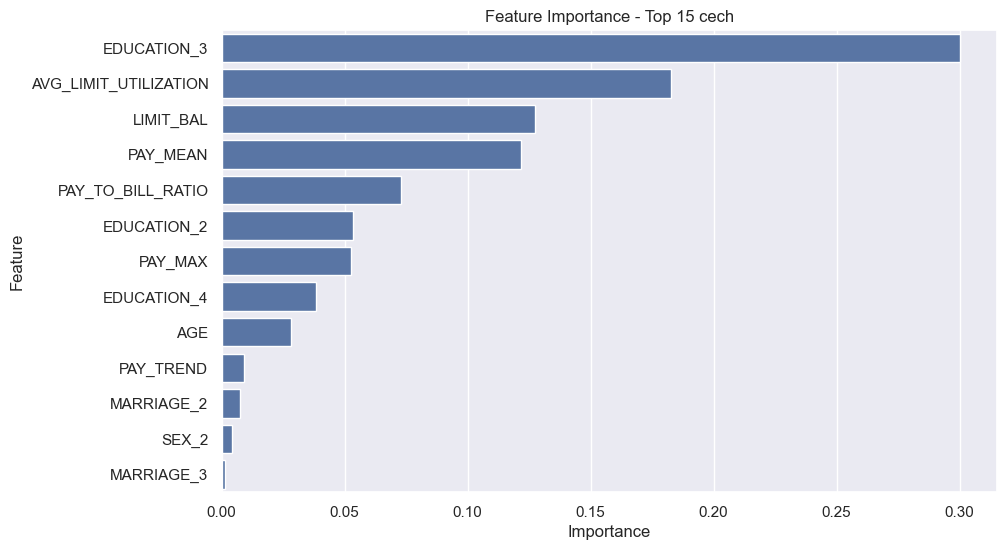

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Top 15 cech')
plt.show()


### Interpretacja

Powyższy ranking pokazuje, które cechy najsilniej wpływają na przypisanie klientów do klastrów. Szczególnie interesujące są zmienne związane z historią płatności (PAY_X), wysokością zadłużenia (BILL_AMT_X) oraz kwotami spłat (PAY_AMT_X).


# 2. SHAP – interpretacja globalna i lokalna

In [7]:
explainer = shap.TreeExplainer(rf)

sample = X_test.sample(
    min(1000, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(sample)


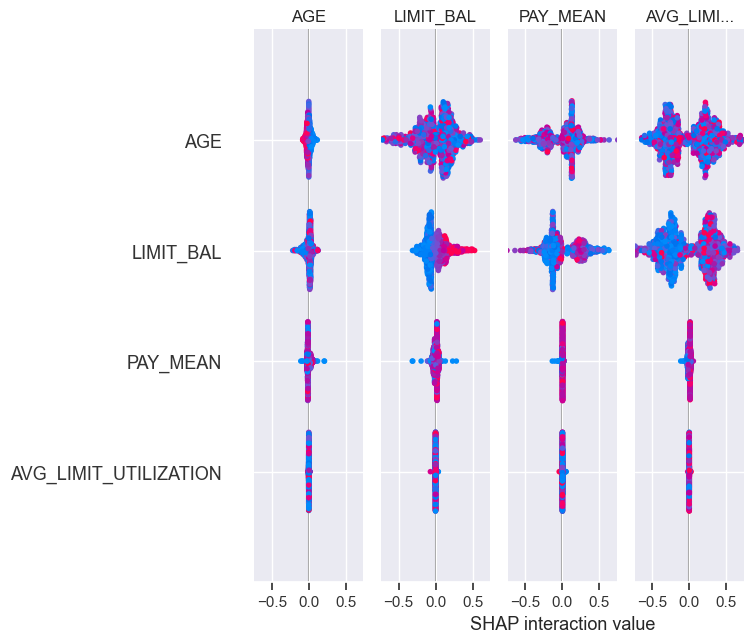

In [8]:
shap.summary_plot(
    shap_values,
    sample,
    show=False
)

plt.tight_layout()
plt.show()


In [9]:
top_feature = importance_df.iloc[0]['Feature']

try:
    shap.dependence_plot(
        top_feature,
        shap_values,
        sample,
        show=False
    )
    plt.show()
except:
    print('Dependence plot nie został wygenerowany.')


Dependence plot nie został wygenerowany.


### Interpretacja SHAP

- Summary Plot przedstawia globalny wpływ cech na decyzje modelu.
- Dependence Plot pokazuje zależność między wartością cechy a jej wpływem na predykcję.
- Dzięki SHAP możliwa jest zarówno interpretacja globalna, jak i analiza pojedynczych przypadków.


# 3. Analiza wpływu zmiennych (Partial Dependence Plot)

Klaster 0


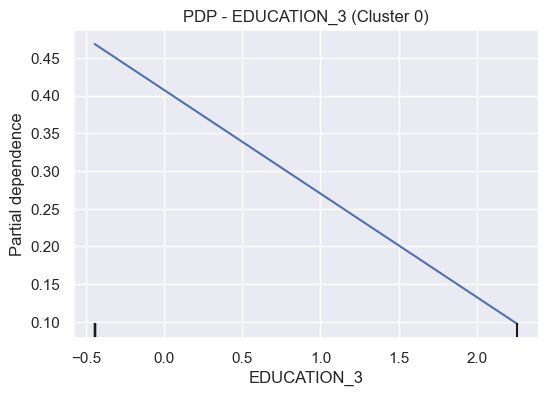

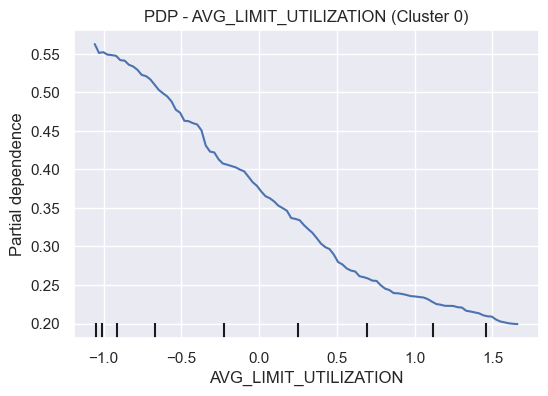

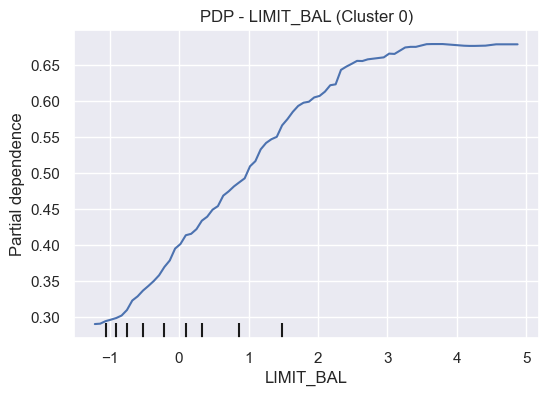

Klaster 1


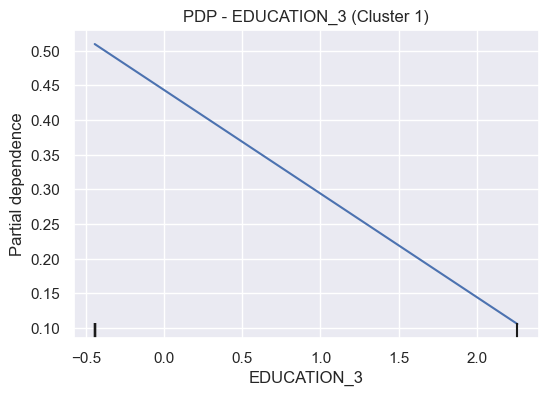

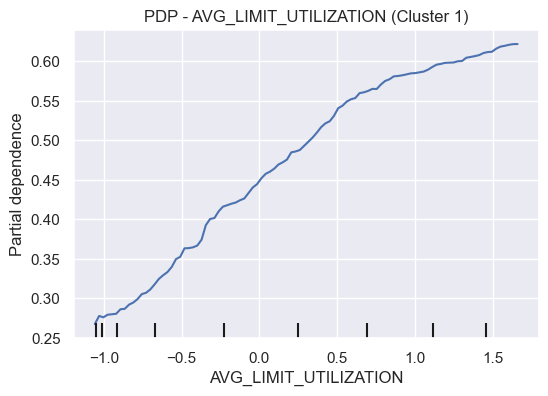

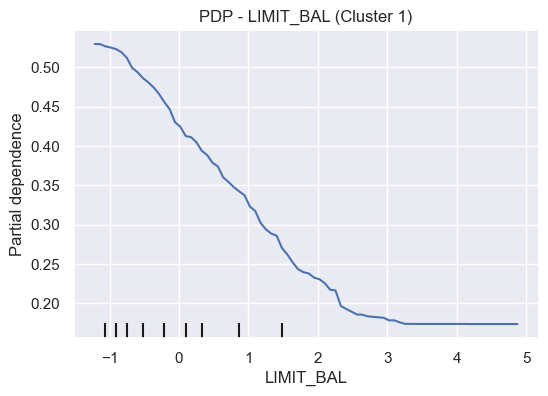

Klaster 2


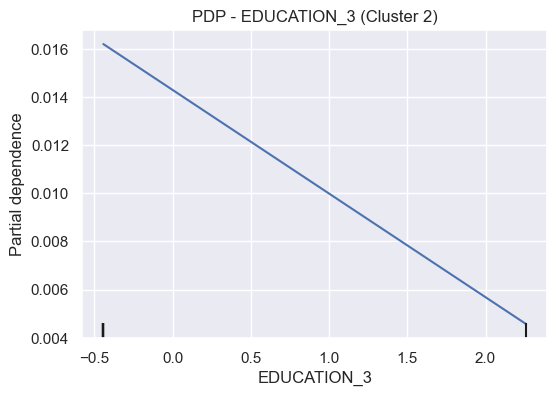

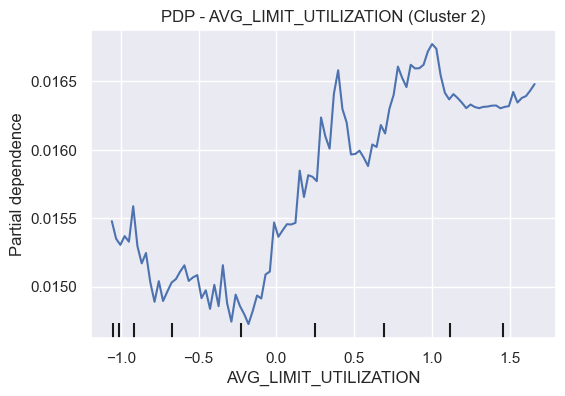

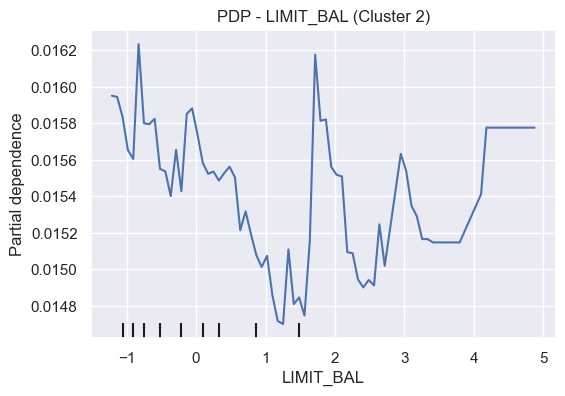

Klaster 3


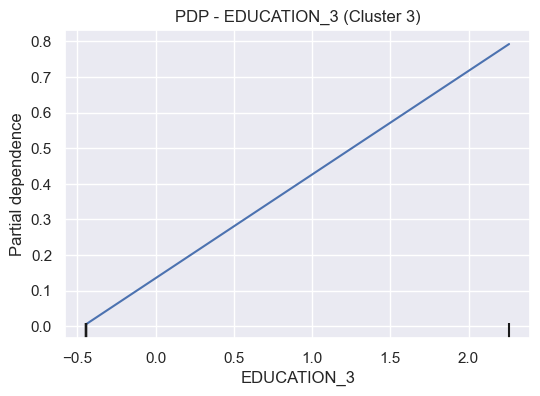

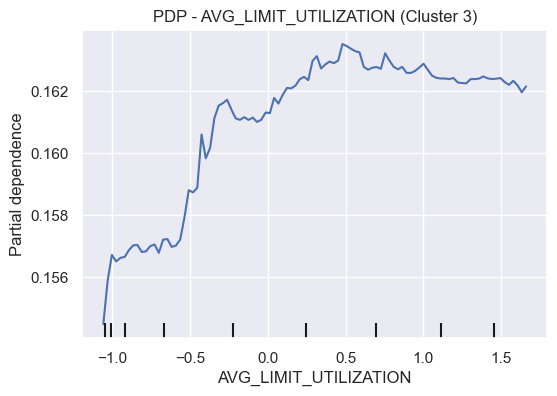

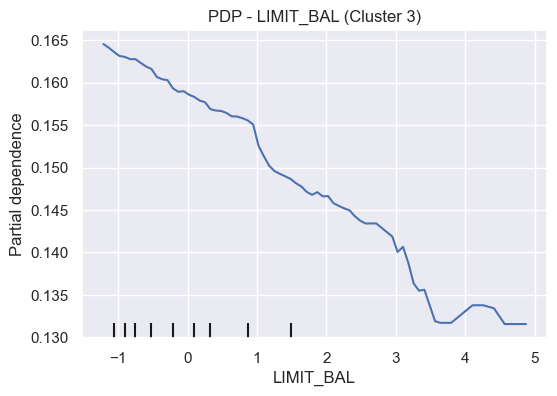

In [11]:
for cluster_id in sorted(np.unique(cluster_labels)):

    print(f"Klaster {cluster_id}")

    for feature in top_features:

        fig, ax = plt.subplots(figsize=(6,4))

        PartialDependenceDisplay.from_estimator(
            rf,
            X_test,
            [feature],
            target=cluster_id,
            ax=ax
        )

        plt.title(
            f"PDP - {feature} (Cluster {cluster_id})"
        )

        plt.show()

### Pytania badawcze

1. Które zmienne mają największy wpływ na przypisanie klienta do klastra?
2. Czy wyniki są zgodne z wiedzą dziedzinową dotyczącą ryzyka kredytowego?
3. Czy wpływ najważniejszych cech jest liniowy czy nieliniowy?
4. Czy istnieją zmienne o marginalnym znaczeniu?


# Wnioski końcowe

## Najważniejsze zmienne
- Feature Importance pozwala wskazać kluczowe cechy wpływające na strukturę klastrów.
- Najczęściej będą to cechy związane z historią spłat oraz poziomem zadłużenia.

## Interpretowalność modelu
- SHAP umożliwia analizę zarówno globalną, jak i lokalną.
- Można wyjaśnić, dlaczego konkretny klient został przypisany do danego klastra.

## Wiarygodność modelu
- Wysoka skuteczność modelu zastępczego oznacza, że struktura klastrów jest możliwa do odtworzenia.
- Ułatwia to interpretację wyników klasteryzacji.

## Ograniczenia
- K-Means jest metodą nienadzorowaną, dlatego interpretacja jest pośrednia.
- Wyniki SHAP dotyczą modelu zastępczego, a nie bezpośrednio algorytmu K-Means.

## Dalsze usprawnienia
- Analiza stabilności klastrów.
- Porównanie interpretacji dla Agglomerative Clustering i DBSCAN.
- Zastosowanie bardziej zaawansowanych metod Explainable AI.
